Nombre: Analisis Visual Exploratorio
Fecha: 2026-01-19
Autor: Lucas

Resumen: 


Selección del Conjunto de Datos:
o
Utilizara n el conjunto de datos "penguins" que se puede cargar directamente desde la biblioteca Seaborn: df_pinguinos = sns.load_dataset("penguins").
o
Este dataset contiene informacio n sobre diferentes especies de pingu inos, sus medidas corporales, sexo y la isla donde fueron observados.

In [3]:
import seaborn as sns

df_pinguinos = sns.load_dataset("penguins")
df_pinguinos.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 1. Exploración Inicial del Dataset

Realizaremos una inspección inicial del dataset para comprender su estructura, tipos de datos y estadísticas básicas.

In [4]:
# Información general del dataset
print("=== Información General del Dataset ===")
df_pinguinos.info()

=== Información General del Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [5]:
# Estadísticas descriptivas básicas
print("=== Estadísticas Descriptivas ===")
df_pinguinos.describe()

=== Estadísticas Descriptivas ===


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
# Verificar valores faltantes
print("=== Valores Faltantes por Columna ===")
print(df_pinguinos.isnull().sum())
print(f"\nTotal de filas antes de eliminar valores faltantes: {len(df_pinguinos)}")

# Eliminar filas con valores faltantes
df_pinguinos_clean = df_pinguinos.dropna()
print(f"Total de filas después de eliminar valores faltantes: {len(df_pinguinos_clean)}")
print(f"Filas eliminadas: {len(df_pinguinos) - len(df_pinguinos_clean)}")

=== Valores Faltantes por Columna ===
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total de filas antes de eliminar valores faltantes: 344
Total de filas después de eliminar valores faltantes: 333
Filas eliminadas: 11


## 2. Visualizaciones Exploratorias

A continuación, crearemos diferentes tipos de gráficos para explorar visualmente el dataset de pingüinos.

In [7]:
# Importar librerías necesarias para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### a) Distribución de una Variable Numérica: Longitud de la Aleta

Utilizamos un histograma con Matplotlib para visualizar la distribución de `flipper_length_mm`.

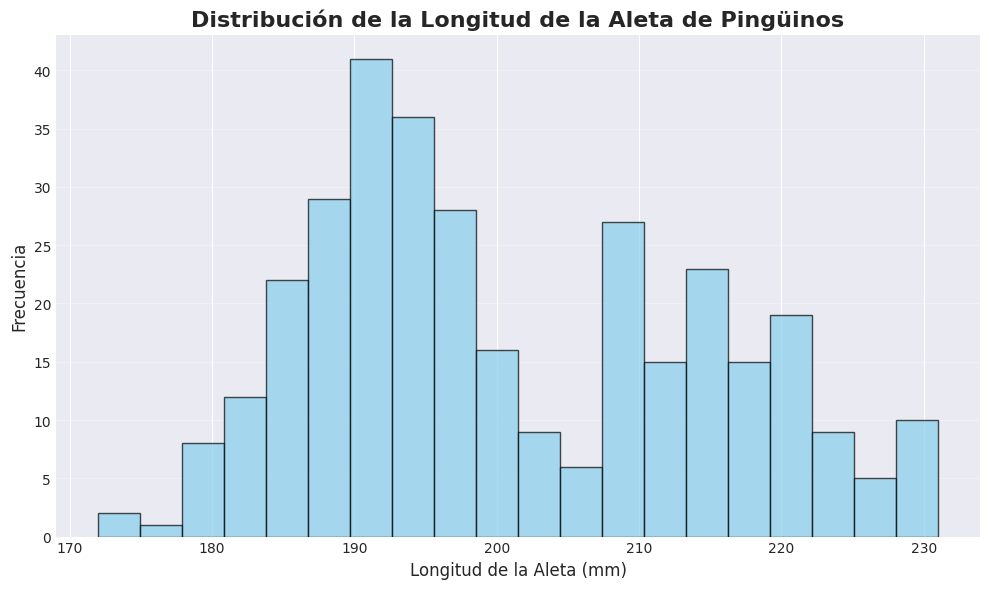


📊 Observaciones:

- La distribución muestra una forma bimodal o multimodal, sugiriendo que podría haber diferentes grupos de pingüinos.

- La mayoría de los pingüinos tienen aletas entre 180-220 mm.

- Esto podría estar relacionado con las diferentes especies presentes en el dataset.


In [8]:
# a) Histograma de flipper_length_mm con Matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df_pinguinos_clean['flipper_length_mm'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Longitud de la Aleta de Pingüinos', fontsize=16, fontweight='bold')
plt.xlabel('Longitud de la Aleta (mm)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("""\n📊 Observaciones:\n
- La distribución muestra una forma bimodal o multimodal, sugiriendo que podría haber diferentes grupos de pingüinos.\n
- La mayoría de los pingüinos tienen aletas entre 180-220 mm.\n
- Esto podría estar relacionado con las diferentes especies presentes en el dataset.""")

### b) Frecuencia de una Variable Categórica: Especies de Pingüinos

Utilizamos un gráfico de barras con Seaborn para mostrar el conteo de pingüinos por especie.

/tmp/ipykernel_4623/184979358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pinguinos_clean, x='species', palette='Set2', edgecolor='black')


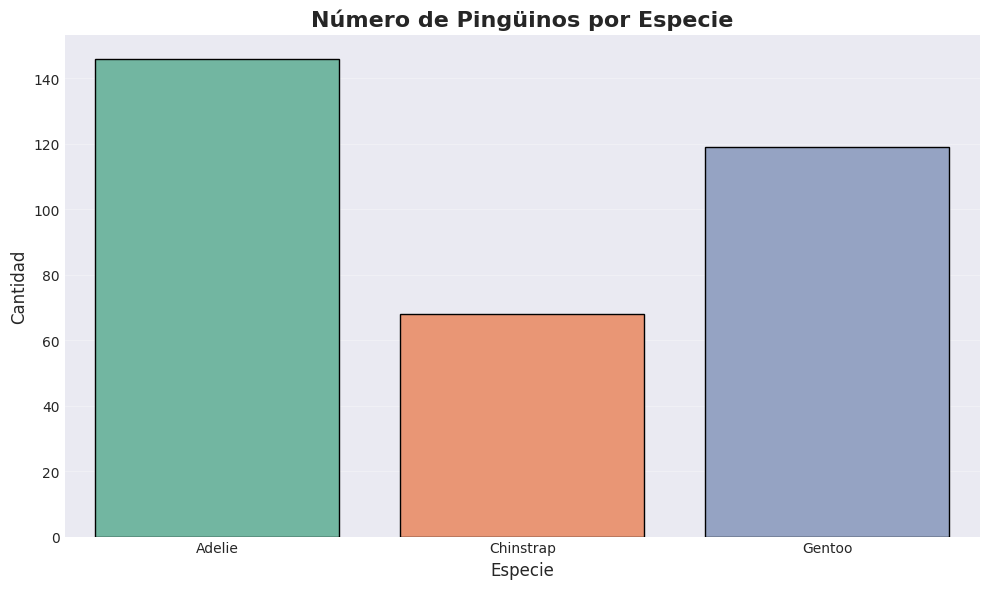


📊 Conteo por Especie:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

📊 Observaciones:

- La especie Adelie es la más abundante en el dataset.

- Las especies Gentoo y Chinstrap tienen representaciones similares.

- El dataset está relativamente balanceado, lo cual es bueno para análisis comparativos.


In [9]:
# b) Gráfico de barras de especies con Seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=df_pinguinos_clean, x='species', palette='Set2', edgecolor='black')
plt.title('Número de Pingüinos por Especie', fontsize=16, fontweight='bold')
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar conteo exacto
print("\n📊 Conteo por Especie:")
print(df_pinguinos_clean['species'].value_counts())
print("""\n📊 Observaciones:\n
- La especie Adelie es la más abundante en el dataset.\n
- Las especies Gentoo y Chinstrap tienen representaciones similares.\n
- El dataset está relativamente balanceado, lo cual es bueno para análisis comparativos.""")

### c) Relación entre Dos Variables Numéricas: Longitud vs Profundidad del Pico

Utilizamos un gráfico de dispersión con Matplotlib para explorar la relación entre `bill_length_mm` y `bill_depth_mm`.

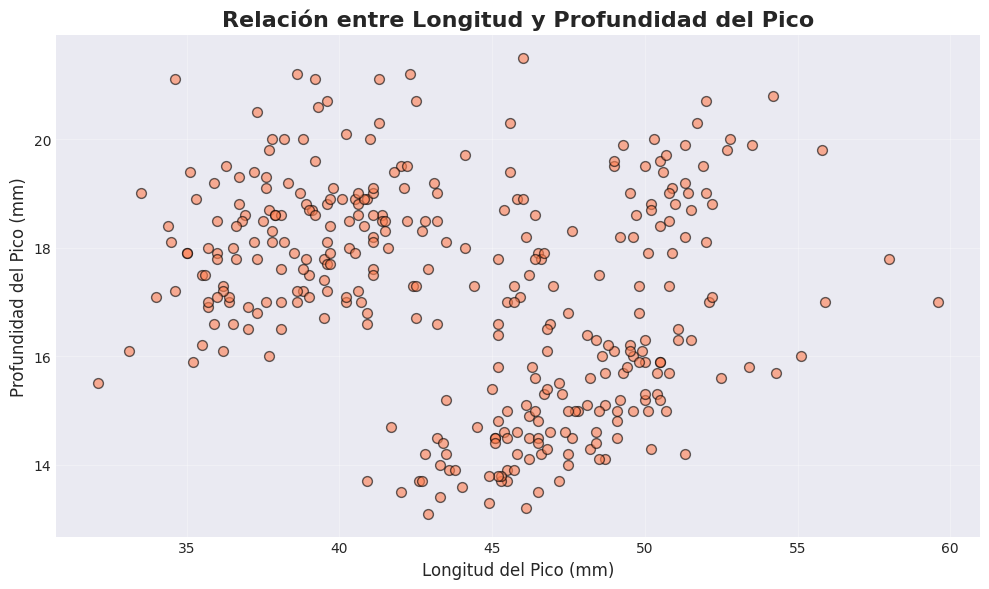


📊 Observaciones:

- Se observan grupos o clusters distintos en el gráfico, lo que sugiere diferencias entre especies.

- No hay una relación lineal simple entre ambas variables cuando se consideran todas las especies juntas.

- Parece haber una paradoja de Simpson: la relación podría ser diferente dentro de cada especie.


In [10]:
# c) Gráfico de dispersión con Matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(df_pinguinos_clean['bill_length_mm'], 
            df_pinguinos_clean['bill_depth_mm'], 
            c='coral', alpha=0.6, edgecolors='black', s=50)
plt.title('Relación entre Longitud y Profundidad del Pico', fontsize=16, fontweight='bold')
plt.xlabel('Longitud del Pico (mm)', fontsize=12)
plt.ylabel('Profundidad del Pico (mm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""\n📊 Observaciones:\n
- Se observan grupos o clusters distintos en el gráfico, lo que sugiere diferencias entre especies.\n
- No hay una relación lineal simple entre ambas variables cuando se consideran todas las especies juntas.\n
- Parece haber una paradoja de Simpson: la relación podría ser diferente dentro de cada especie.""")

### d) Comparación de Masa Corporal entre Especies: Boxplot

Utilizamos un diagrama de caja con Seaborn para comparar la distribución de `body_mass_g` entre las diferentes especies.

/tmp/ipykernel_4623/19544946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pinguinos_clean, x='species', y='body_mass_g', palette='Set3', linewidth=2)


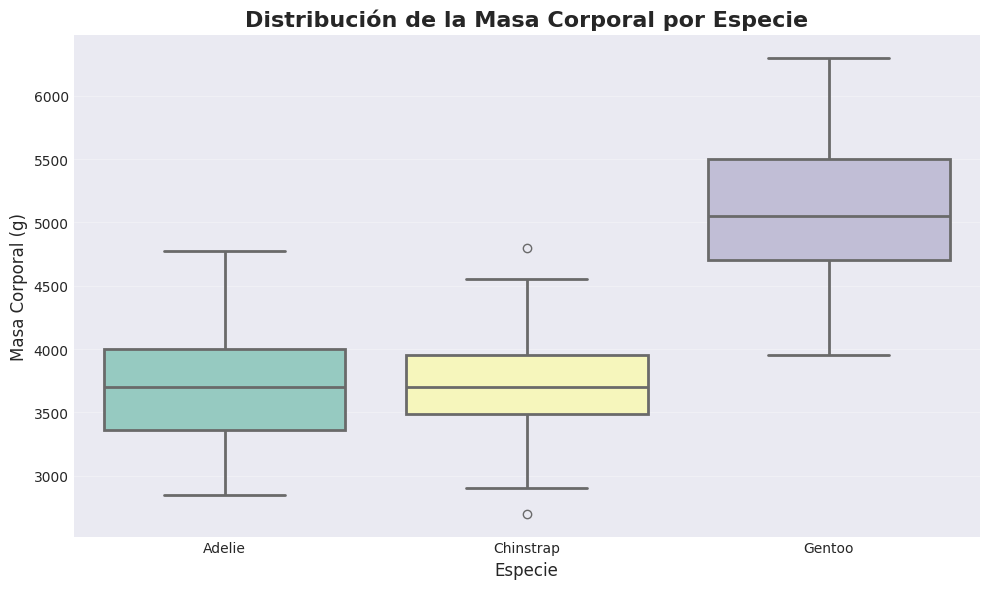


📊 Observaciones:

- Los pingüinos Gentoo son significativamente más pesados que las otras dos especies.

- Los pingüinos Adelie y Chinstrap tienen masas corporales similares, aunque Chinstrap tiene una mediana ligeramente mayor.

- Se observan algunos valores atípicos (outliers) en las tres especies.

- La variabilidad (rango intercuartílico) es similar entre especies.


In [11]:
# d) Boxplot de body_mass_g por species con Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_pinguinos_clean, x='species', y='body_mass_g', palette='Set3', linewidth=2)
plt.title('Distribución de la Masa Corporal por Especie', fontsize=16, fontweight='bold')
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Masa Corporal (g)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("""\n📊 Observaciones:\n
- Los pingüinos Gentoo son significativamente más pesados que las otras dos especies.\n
- Los pingüinos Adelie y Chinstrap tienen masas corporales similares, aunque Chinstrap tiene una mediana ligeramente mayor.\n
- Se observan algunos valores atípicos (outliers) en las tres especies.\n
- La variabilidad (rango intercuartílico) es similar entre especies.""")

### e) Comparación de Masa Corporal entre Especies y Sexo: Gráfico de Violín

Utilizamos un gráfico de violín con Seaborn para comparar `body_mass_g` entre especies, diferenciando por sexo.

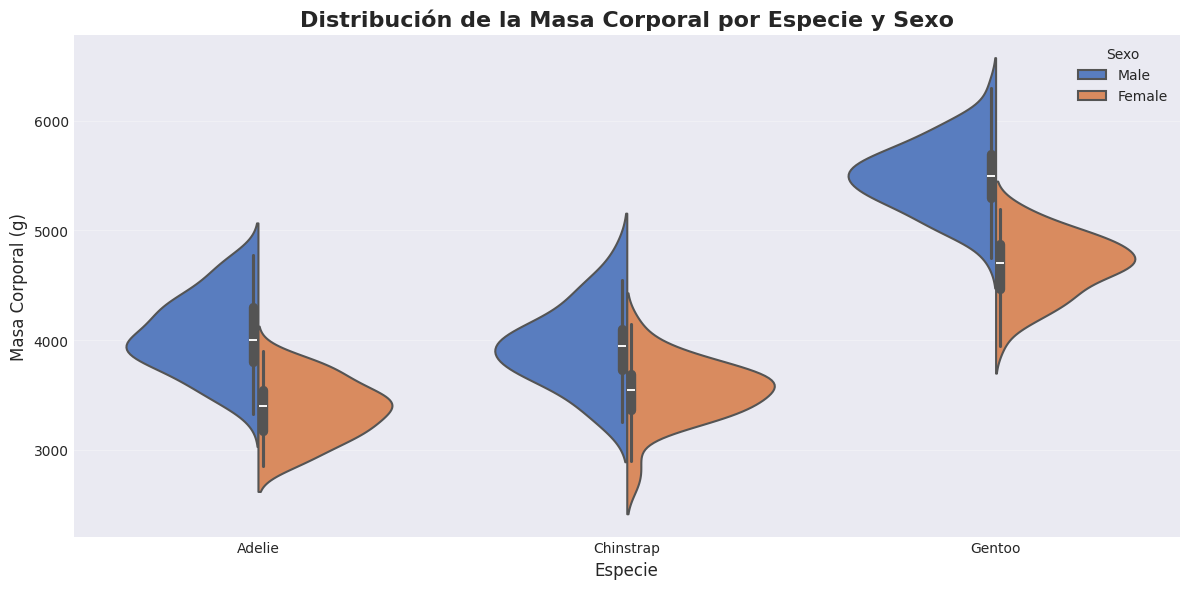


📊 Observaciones:

- En todas las especies, los machos (Male) tienden a ser más pesados que las hembras (Female).

- La diferencia de masa entre sexos es más pronunciada en la especie Gentoo.

- Las distribuciones son relativamente simétricas, con algunas variaciones en la densidad.

- Los gráficos de violín permiten ver la densidad de la distribución, mostrando dónde se concentran más los datos.

- El dimorfismo sexual (diferencia entre sexos) es evidente en las tres especies.


In [12]:
# e) Gráfico de violín con diferenciación por sexo
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_pinguinos_clean, x='species', y='body_mass_g', hue='sex', 
               palette='muted', split=True, linewidth=1.5)
plt.title('Distribución de la Masa Corporal por Especie y Sexo', fontsize=16, fontweight='bold')
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Masa Corporal (g)', fontsize=12)
plt.legend(title='Sexo', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("""\n📊 Observaciones:\n
- En todas las especies, los machos (Male) tienden a ser más pesados que las hembras (Female).\n
- La diferencia de masa entre sexos es más pronunciada en la especie Gentoo.\n
- Las distribuciones son relativamente simétricas, con algunas variaciones en la densidad.\n
- Los gráficos de violín permiten ver la densidad de la distribución, mostrando dónde se concentran más los datos.\n
- El dimorfismo sexual (diferencia entre sexos) es evidente en las tres especies.""")

## 3. Conclusiones del Análisis Visual Exploratorio

### Hallazgos Principales:

1. **Dataset**: Contiene información de 3 especies de pingüinos con 7 variables (especies, isla, medidas del pico, longitud de aleta, masa corporal y sexo).

2. **Valores Faltantes**: Se eliminaron filas con valores faltantes para simplificar el análisis.

3. **Diferencias entre Especies**:
   - Los pingüinos **Gentoo** son notablemente más grandes y pesados.
   - Las especies **Adelie** y **Chinstrap** son más similares en tamaño.

4. **Dimorfismo Sexual**: Los machos son consistentemente más pesados que las hembras en todas las especies.

5. **Distribuciones**: Las variables numéricas muestran distribuciones que reflejan las diferencias entre especies y sexos.

### Próximos Pasos:
- Análisis de correlaciones entre variables
- Modelado predictivo para clasificación de especies
- Análisis más profundo de las diferencias entre islas

### e) Mapa de Calor de Correlaciones

Calculamos y visualizamos la matriz de correlación de las variables numéricas utilizando un mapa de calor de Seaborn.

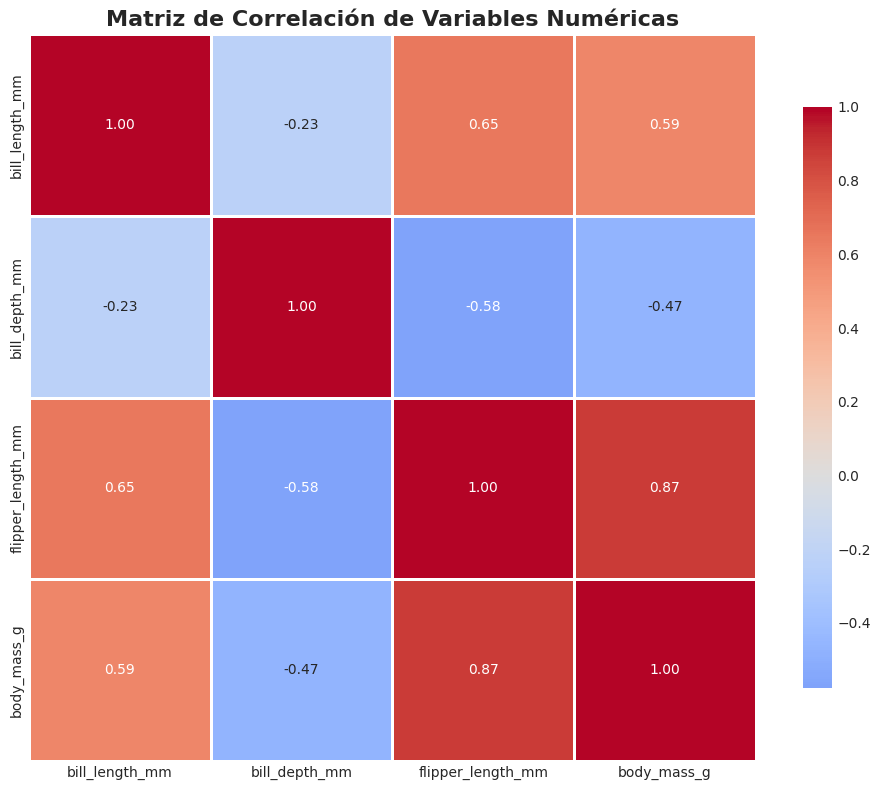


📊 Observaciones:

- **Correlaciones Fuertes Positivas**:

  • flipper_length_mm y body_mass_g tienen una correlación muy alta (~0.87), indicando que pingüinos con aletas más largas tienden a ser más pesados.

  • bill_length_mm y flipper_length_mm también muestran correlación positiva moderada-alta.



- **Correlaciones Negativas**:

  • bill_depth_mm muestra correlaciones negativas con bill_length_mm y flipper_length_mm.

  • Esto podría deberse a diferencias entre especies (paradoja de Simpson).



- **Implicaciones**:

  • Las variables están relacionadas de manera compleja, reflejando las características morfológicas de cada especie.

  • Para modelos predictivos, algunas variables podrían ser redundantes debido a la multicolinealidad.


In [13]:
# e) Mapa de calor de correlaciones con Seaborn
import numpy as np

# Calcular la matriz de correlación de las variables numéricas
correlation_matrix = df_pinguinos_clean.select_dtypes(include=[np.number]).corr()

# Crear el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # Mostrar valores de correlación
            fmt='.2f',   # Formato de 2 decimales
            cmap='coolwarm',  # Paleta de colores
            center=0,    # Centrar en 0
            square=True, # Celdas cuadradas
            linewidths=1,  # Líneas entre celdas
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("""\n📊 Observaciones:\n
- **Correlaciones Fuertes Positivas**:\n
  • flipper_length_mm y body_mass_g tienen una correlación muy alta (~0.87), indicando que pingüinos con aletas más largas tienden a ser más pesados.\n
  • bill_length_mm y flipper_length_mm también muestran correlación positiva moderada-alta.\n
\n
- **Correlaciones Negativas**:\n
  • bill_depth_mm muestra correlaciones negativas con bill_length_mm y flipper_length_mm.\n
  • Esto podría deberse a diferencias entre especies (paradoja de Simpson).\n
\n
- **Implicaciones**:\n
  • Las variables están relacionadas de manera compleja, reflejando las características morfológicas de cada especie.\n
  • Para modelos predictivos, algunas variables podrían ser redundantes debido a la multicolinealidad.""")

### f) Figura con Múltiples Gráficos (Subplots)

Creamos una figura con dos subparcelas para mostrar diferentes visualizaciones en un mismo espacio.

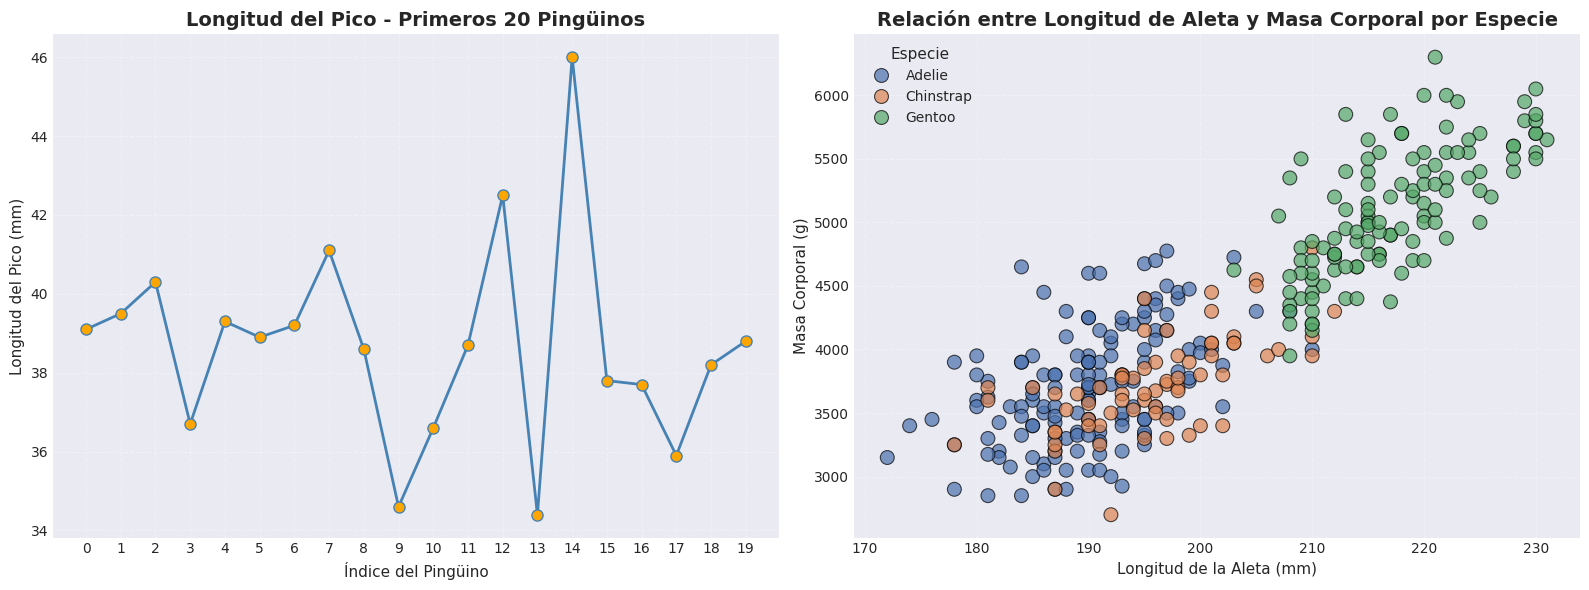


📊 Observaciones:


**Subparcela 1 - Gráfico de Líneas:**

- Muestra la variabilidad en la longitud del pico entre los primeros 20 pingüinos del dataset.

- Se pueden observar fluctuaciones que reflejan las diferencias individuales y posiblemente entre especies.


**Subparcela 2 - Gráfico de Dispersión por Especie:**

- Se observan tres clusters claramente diferenciados correspondientes a las tres especies.

- **Gentoo** (naranja): Aletas más largas y mayor masa corporal.

- **Adelie** (azul): Aletas más cortas y menor masa corporal.

- **Chinstrap** (verde): Características intermedias.

- La correlación positiva entre longitud de aleta y masa corporal es evidente en todas las especies.

- Esta visualización confirma que estas dos variables son buenos predictores para clasificar especies.


In [14]:
# f) Figura con múltiples gráficos (subplots)
import numpy as np

# Crear figura con 2 subparcelas (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subparcela 1: Gráfico de líneas ---
# Longitud del pico de los primeros 20 pingüinos
primeros_20 = df_pinguinos_clean.head(20)
indices = np.arange(len(primeros_20))

axes[0].plot(indices, primeros_20['bill_length_mm'], 
             marker='o', linestyle='-', linewidth=2, 
             markersize=8, color='steelblue', markerfacecolor='orange')
axes[0].set_title('Longitud del Pico - Primeros 20 Pingüinos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Índice del Pingüino', fontsize=11)
axes[0].set_ylabel('Longitud del Pico (mm)', fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(indices)

# --- Subparcela 2: Gráfico de dispersión coloreado por especie ---
# Usar Seaborn dentro de la subparcela de Matplotlib
sns.scatterplot(data=df_pinguinos_clean, 
                x='flipper_length_mm', 
                y='body_mass_g', 
                hue='species',
                palette='deep',
                s=100,
                alpha=0.7,
                edgecolor='black',
                ax=axes[1])
axes[1].set_title('Relación entre Longitud de Aleta y Masa Corporal por Especie', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitud de la Aleta (mm)', fontsize=11)
axes[1].set_ylabel('Masa Corporal (g)', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(title='Especie', fontsize=10, title_fontsize=11)

# Ajustar espaciado
plt.tight_layout()
plt.show()

print("""\n📊 Observaciones:\n
\n**Subparcela 1 - Gráfico de Líneas:**\n
- Muestra la variabilidad en la longitud del pico entre los primeros 20 pingüinos del dataset.\n
- Se pueden observar fluctuaciones que reflejan las diferencias individuales y posiblemente entre especies.\n
\n**Subparcela 2 - Gráfico de Dispersión por Especie:**\n
- Se observan tres clusters claramente diferenciados correspondientes a las tres especies.\n
- **Gentoo** (naranja): Aletas más largas y mayor masa corporal.\n
- **Adelie** (azul): Aletas más cortas y menor masa corporal.\n
- **Chinstrap** (verde): Características intermedias.\n
- La correlación positiva entre longitud de aleta y masa corporal es evidente en todas las especies.\n
- Esta visualización confirma que estas dos variables son buenos predictores para clasificar especies.""")

---

## 🎯 Resumen Final del Análisis Visual Exploratorio

### Visualizaciones Completadas:

✅ **a) Histograma** - Distribución de `flipper_length_mm` (Matplotlib)  
✅ **b) Gráfico de Barras** - Frecuencia por `species` (Seaborn)  
✅ **c) Gráfico de Dispersión** - `bill_length_mm` vs `bill_depth_mm` (Matplotlib)  
✅ **d) Boxplot** - `body_mass_g` por `species` (Seaborn)  
✅ **e) Gráfico de Violín** - `body_mass_g` por `species` y `sex` (Seaborn)  
✅ **f) Mapa de Calor** - Matriz de correlaciones (Seaborn)  
✅ **g) Subplots** - Múltiples gráficos en una figura (Matplotlib)  

### Insights Clave:

1. **Diferenciación por Especies**: Las tres especies de pingüinos tienen características morfológicas distintivas que permiten su clasificación.

2. **Dimorfismo Sexual**: Los machos son consistentemente más pesados que las hembras en todas las especies.

3. **Correlaciones Importantes**: 
   - Fuerte correlación positiva entre longitud de aleta y masa corporal
   - Correlaciones negativas inesperadas que reflejan diferencias entre especies

4. **Calidad de Datos**: Dataset relativamente limpio y balanceado, ideal para análisis y modelado.

### Herramientas Utilizadas:

- **Matplotlib**: Para gráficos básicos con control detallado (histogramas, scatter plots, line plots, subplots)
- **Seaborn**: Para visualizaciones estadísticas avanzadas (boxplots, violin plots, heatmaps, count plots)
- **Pandas**: Para manipulación y análisis de datos
- **NumPy**: Para operaciones numéricas

---

**📚 Ejercicio completado exitosamente!**